# Photochem Non-Convergence Diagnostics

Loads `PICASOLimits_ReportFiles/photochem_not_converged_cases.npy`, filters to metallicities ≤ 2.375 (log10 Z/Zsun), selects one case, and reruns Photochem with checkpoint snapshots to diagnose which species are preventing convergence.

**Workflow:**
1. Load + filter not-converged cases by metallicity
2. Pick a single case to investigate (`CASE_IDX`)
3. Rerun Photochem in stages: 100 → 500 → 1000 → 2000 → 5000 → 10,000 steps
4. Plot all species mixing ratios at each stage to identify what is not settling
5. Quantify which species depart most from equilibrium at the final step
6. (Isolated case section) Re-run PICASO fresh for a suspect PT profile, then run Photochem on the new output

**Note** I used the python environment of subneptune_picaso_updated. It is possible that I won't be able to use this environment for rerunning picaso though. 

In [1]:
import sys
import os
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pickle

warnings.filterwarnings('ignore')

_root = Path.cwd()
sys.path.insert(0, str(_root / 'MiniNepGrid_Scripts'))

os.environ['picaso_refdata'] = str(_root / 'Installation_Setup_Instructions/picasofiles/reference')
os.environ['PYSYN_CDBS']    = str(_root / 'Installation_Setup_Instructions/picasofiles/grp/redcat/trds')

In [2]:
from photochem.utils import zahnle_rx_and_thermo_files
from photochem.extensions import gasgiants
import PICASO_Climate_grid_121625 as PICASO_Climate_grid
import Photochem_grid_121625 as Photochem_grid
import star_spectrum

/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds


## Part 1: Find Photochem Cases that did not converge

In [3]:
# Create list of cases that did not converge

import h5py
import numpy as np
from pathlib import Path

PC_H5 = 'data/grid_results/Photochem_1D_lowmetal_restart.h5'
grid_shape = (1, 6, 8, 11, 5, 3)  # low-metal grid shape

with h5py.File(PC_H5, 'r') as f:
    inputs    = f['inputs'][:]          # (N, 6)
    completed = f['completed'][:]       # (N,)
    status    = f['results/status'][...]

status_flat = status.reshape(np.prod(grid_shape))

not_converged = []
for i in range(len(inputs)):
    if completed[i]:
        s = status_flat[i].flat[0]
        if isinstance(s, (bytes, np.bytes_)):
            s = s.decode()
        if s == 'Photochem-not-converged':
            not_converged.append(inputs[i])

not_converged = np.array(not_converged)
Path('PICASOLimits_ReportFiles').mkdir(exist_ok=True)
np.save('PICASOLimits_ReportFiles/photochem_not_converged_cases_lowmetal_restart_postHYAK.npy', not_converged)

print(f"Saved {len(not_converged)} not-converged cases")


Saved 151 not-converged cases


In [ ]:
# Status summary and worker exception cases from the completed Hyak run
from collections import Counter

with h5py.File(PC_H5, 'r') as f:
    _inputs    = f['inputs'][:]
    _completed = f['completed'][:]
    _status    = f['results/status'][...]
    _error     = f['results/error'][...]

_status_flat = _status.reshape(np.prod(grid_shape))
_error_flat  = _error.reshape(np.prod(grid_shape))

# Overall status breakdown
all_statuses = []
for i in range(len(_inputs)):
    if _completed[i]:
        s = _status_flat[i].flat[0]
        if isinstance(s, (bytes, np.bytes_)):
            s = s.decode()
        all_statuses.append(s)

counts = Counter(all_statuses)
print(f'Completed: {_completed.sum()} / {len(_completed)}')
print()
print('Status breakdown:')
for s, n in counts.most_common():
    print(f'  {s:<35}  {n:>5} cases')
print()

# Worker exception cases
worker_exceptions = []
for i in range(len(_inputs)):
    if _completed[i]:
        s = _status_flat[i].flat[0]
        if isinstance(s, (bytes, np.bytes_)):
            s = s.decode()
        if s == 'worker_exception':
            e = _error_flat[i].flat[0]
            if isinstance(e, (bytes, np.bytes_)):
                e = e.decode()
            worker_exceptions.append((_inputs[i], e))

print(f'Worker exception cases ({len(worker_exceptions)} total — caused by network errors on Hyak):')
print(f'{"#":>3}  {"rad":>5}  {"log10Z":>7}  {"Tint":>6}  {"a(AU)":>6}  {"C/O":>6}  {"logKzz":>7}  Error')
print('-' * 115)
for idx, (row, err) in enumerate(worker_exceptions):
    r, z, t, a, c, k = row
    print(f'{idx:>3}  {r:>5.2f}  {z:>7.4f}  {t:>6.1f}  {a:>6.2f}  {c:>6.4f}  {k:>7.1f}  {err[:65]}')

# Save worker exception inputs for potential rerunning
worker_exception_inputs = np.array([row for row, _ in worker_exceptions])
np.save('PICASOLimits_ReportFiles/worker_exception_cases_lowmetal_restart.npy', worker_exception_inputs)
print(f'\nSaved to PICASOLimits_ReportFiles/worker_exception_cases_lowmetal_restart.npy')

In [4]:
cases = np.load('PICASOLimits_ReportFiles/photochem_not_converged_cases_lowmetal_restart_postHYAK.npy')
# columns: [rad(Re), log10(Z/Zsun), Tint(K), semi_major(AU), C/O(solar), log10(Kzz)]

METAL_MAX = 2.375
filtered  = cases[cases[:, 1] <= METAL_MAX]

print(f'Total not-converged cases loaded:     {len(cases)}')
print(f'After filtering log10(Z) <= {METAL_MAX}: {len(filtered)} cases')
print()
print('Count by log10(Z):')
for z in sorted(np.unique(filtered[:, 1])):
    n = int(np.sum(filtered[:, 1] == z))
    print(f'  log10(Z) = {z:.4f}  ({10**z:7.1f}x solar)  ->  {n} cases')

Total not-converged cases loaded:     151
After filtering log10(Z) <= 2.375: 151 cases

Count by log10(Z):
  log10(Z) = 0.5000  (    3.2x solar)  ->  10 cases
  log10(Z) = 0.8750  (    7.5x solar)  ->  3 cases
  log10(Z) = 1.2500  (   17.8x solar)  ->  1 cases
  log10(Z) = 1.6250  (   42.2x solar)  ->  3 cases
  log10(Z) = 2.0000  (  100.0x solar)  ->  42 cases
  log10(Z) = 2.3750  (  237.1x solar)  ->  92 cases


In [5]:
print(f'All {len(filtered)} filtered cases:')
print(f'{"#":>4}  {"rad(Re)":>7}  {"log10Z":>7}  {"Tint(K)":>8}  {"a(AU)":>6}  {"C/O":>6}  {"log_Kzz":>8}')
print('-' * 62)
for i, row in enumerate(filtered):
    r, z, t, a, c, k = row
    print(f'{i:>4}  {r:>7.2f}  {z:>7.4f}  {t:>8.1f}  {a:>6.2f}  {c:>6.4f}  {k:>8.1f}')

All 151 filtered cases:
   #  rad(Re)   log10Z   Tint(K)   a(AU)     C/O   log_Kzz
--------------------------------------------------------------
   0     2.00   0.5000      50.0    8.00  0.0100       9.0
   1     2.00   0.5000      50.0   10.00  0.0100       7.0
   2     2.00   0.5000      50.0   10.00  0.0100       9.0
   3     2.00   0.5000      50.0   10.00  0.2575       9.0
   4     2.00   0.5000      50.0   10.00  0.5050       9.0
   5     2.00   0.5000      50.0   10.00  0.7525       9.0
   6     2.00   0.5000      50.0   10.00  1.0000       9.0
   7     2.00   0.5000     100.0   10.00  0.0100       9.0
   8     2.00   0.5000     100.0   10.00  0.2575       9.0
   9     2.00   0.5000     100.0   10.00  0.5050       9.0
  10     2.00   0.8750      50.0   10.00  0.0100       7.0
  11     2.00   0.8750      50.0   10.00  0.0100       9.0
  12     2.00   0.8750      50.0   10.00  0.2575       9.0
  13     2.00   1.2500      50.0   10.00  0.0100       9.0
  14     2.00   1.6250      

In [6]:
CASE_IDX = 0   # <- change this to investigate a different case (0-8)

rad, log_metal, tint, semi_major, ctoO, log_Kzz = filtered[CASE_IDX]

print(f'Selected case {CASE_IDX}:')
print(f'  Radius:       {rad} Earth radii')
print(f'  Metallicity:  10^{log_metal:.4f} = {10**log_metal:.1f}x solar')
print(f'  Tint:         {tint} K')
print(f'  Semi-major:   {semi_major} AU')
print(f'  C/O:          {ctoO}')
print(f'  log10(Kzz):   {log_Kzz}  ->  Kzz = {10**log_Kzz:.0e} cm^2/s')

Selected case 0:
  Radius:       2.0 Earth radii
  Metallicity:  10^0.5000 = 3.2x solar
  Tint:         50.0 K
  Semi-major:   8.0 AU
  C/O:          0.01
  log10(Kzz):   9.0  ->  Kzz = 1e+09 cm^2/s


In [7]:
## Re-run Photochem as the Grid Did

In [8]:
PICASO_H5 = 'data/grid_results/PICASO_climate_updatop_full_exploration_reducedrad_solveSegFault.h5'

In [ ]:
sol, soleq, pc, convergence_values, converged_PC_arr, pc_status, error = Photochem_grid.Photochem_Gas_Giant(
    rad_plan=rad,
    log10_planet_metallicity=log_metal,
    tint=tint,
    semi_major=semi_major,
    ctoO=ctoO,
    log_Kzz=log_Kzz,
    PT_filename=PICASO_H5,
)
print(f'Status:    {pc_status}')
print(f'Error:     {error!r}')
print(f'Converged: {bool(converged_PC_arr[0]) if converged_PC_arr is not None else "N/A"}')

## Step-by-Step Diagnostic Run

Replicates `Photochem_Gas_Giant` from `MiniNepGrid_Scripts/Photochem_grid_121625.py` exactly.

Each `find_steady_state()` call resets the ODE integrator's step-size controller and Jacobian,
so calling it multiple times with increasing budgets (e.g., 100 → 500 → 1000…) produces a
**different numerical path** than the single 10,000-step call the grid script makes.
To match the grid script, we run once at 10,000 steps, then retry at the same budgets
the grid script uses: 12,000 → 15,000 → 20,000 → 30,000 → 50,000.

Snapshots are captured after each call, giving 6 points (10k, 12k, 15k, 20k, 30k, 50k) —
fewer intermediate steps, but numerically identical behavior to the grid run.

In [13]:
# --- 1. Fetch PICASO PT profile (identical to grid script) ---
PT_list, conv_vals, picaso_status, picaso_error = Photochem_grid.find_PT_grid(
    filename=PICASO_H5,
    rad_plan=rad,
    log10_planet_metallicity=log_metal,
    tint=tint,
    semi_major=semi_major,
    ctoO=ctoO,
    gridvals=PICASO_Climate_grid.get_gridvals_PICASO_TP()
)

if PT_list is None:
    raise RuntimeError(f'PICASO PT not found — status: {picaso_status}, error: {picaso_error}')

print(f'PICASO status:     {picaso_status}')
print(f'Pressure range:    {PT_list[0].min():.3e} – {PT_list[0].max():.3e} bar')
print(f'Temperature range: {PT_list[1].min():.1f} – {PT_list[1].max():.1f} K')

# Extend and convert units (same as Photochem_Gas_Giant)
P_ext, T_ext = Photochem_grid.linear_extrapolate_TP(PT_list[0], PT_list[1])
P_diag = np.flip(P_ext * 1e6).copy()   # bars -> dynes/cm^2, descending
T_diag = np.flip(T_ext).copy()

Was able to successfully find your input parameters in the PICASO TP profile grid!
PICASO status:     PICASO-converged
Pressure range:    1.000e-06 – 1.000e+03 bar
Temperature range: 55.3 – 1109.4 K


In [14]:
# --- 2. Stellar flux file + photochem chemistry files (cached if already present) ---
planet_Teq        = PICASO_Climate_grid.calc_Teq_SUN(distance_AU=semi_major)
stellar_flux_file = f'sun_flux_file_{planet_Teq}'
if not Path(stellar_flux_file).exists():
    print(f'Generating stellar flux file for Teq = {planet_Teq:.1f} K ...')
    star_spectrum.solar_spectrum(Teq=planet_Teq, outputfile=stellar_flux_file)
print(f'Teq = {planet_Teq:.1f} K  |  flux file: {stellar_flux_file}')

atoms_names = ['H', 'He', 'N', 'O', 'C']
zahnle_rx_and_thermo_files(
    atoms_names=atoms_names,
    rxns_filename='photochem_rxns.yaml',
    thermo_filename='photochem_thermo.yaml',
    remove_reaction_particles=True
)
print('Reaction and thermo files ready.')

Teq = 98.5 K  |  flux file: sun_flux_file_98.51925787320911
Reaction and thermo files ready.


In [15]:
# --- 3. Build EvoAtmosphereGasGiant — identical settings to Photochem_Gas_Giant ---
mass_planet_earth = PICASO_Climate_grid.mass_from_radius_chen_kipping_2017(R_rearth=rad)
mass_planet       = mass_planet_earth * 5.972e+24 * 1e3   # Earth masses -> g
radius_planet     = rad * 6.371e+6 * 1e2                  # Earth radii  -> cm

pc_diag = gasgiants.EvoAtmosphereGasGiant(
    mechanism_file='photochem_rxns.yaml',
    stellar_flux_file=stellar_flux_file,
    planet_mass=mass_planet,
    planet_radius=radius_planet,
    solar_zenith_angle=60,
    thermo_file='photochem_thermo.yaml'
)

pc_diag.var.conv_longdy    = 0.03
pc_diag.gdat.verbose       = False
particle_radius            = pc_diag.var.particle_radius
particle_radius[:, :]      = 1e-3   # 10 microns (same as grid script)
pc_diag.var.particle_radius = particle_radius

molfracs_atoms_sun = np.ones(len(pc_diag.gdat.gas.atoms_names)) * 1e-10
comp = {'H': 9.21e-01, 'N': 6.23e-05, 'O': 4.51e-04,
        'C': 2.48e-04, 'S': 1.21e-05, 'He': 7.84e-02}
tot = sum(comp.values())
for i_atom, atom in enumerate(pc_diag.gdat.gas.atoms_names):
    molfracs_atoms_sun[i_atom] = comp.get(atom, 1e-10) / tot
pc_diag.gdat.gas.molfracs_atoms_sun = molfracs_atoms_sun

Kzz_diag = np.ones(P_diag.shape[0]) * (10 ** log_Kzz)
pc_diag.gdat.BOA_pressure_factor = 3
pc_diag.initialize_to_climate_equilibrium_PT(P_diag, T_diag, Kzz_diag, 10 ** log_metal, ctoO)
print('Model initialized to chemical equilibrium. Ready to run.')

Model initialized to chemical equilibrium. Ready to run.


In [16]:
# --- 4. Checkpoint run — identical to Photochem_Gas_Giant in the grid script ---
#
# Step 1: single find_steady_state() call at 10,000 steps (same as grid script first call).
# Step 2: if not converged, retry with the same budgets the grid script uses.
# A snapshot is saved after each call so we can see how the mixing ratios evolve.

soleq_diag  = pc_diag.return_atmosphere(equilibrium=True)
mol_species = sorted([k for k in soleq_diag.keys() if k not in ('pressure', 'temperature', 'Kzz')])
print(f'Species tracked ({len(mol_species)} total): {mol_species}')

snapshots      = {}   # step_count -> raw atmosphere dict
converged_diag = False

# --- Step 1: initial 10,000-step run (matches grid script) ---
pc_diag.gdat.max_total_step = 10000
converged_diag = pc_diag.find_steady_state()
steps_done = pc_diag.gdat.total_step_counter
snapshots[steps_done] = pc_diag.return_atmosphere()
print(f'Initial run:  steps done={steps_done}  {"CONVERGED" if converged_diag else "not converged"}')

# --- Step 2: retry budgets (same as grid script) ---
if not converged_diag:
    retry_budgets = [12000, 15000, 20000, 30000, 50000]
    for budget in retry_budgets:
        try:
            pc_diag.gdat.max_total_step = budget
            converged_diag = pc_diag.find_steady_state()
            steps_done = pc_diag.gdat.total_step_counter
            snapshots[steps_done] = pc_diag.return_atmosphere()
            status_str = 'CONVERGED' if converged_diag else 'not converged'
            print(f'Retry budget={budget:>6}  steps done={steps_done:>6}  {status_str}')
            if converged_diag:
                print('  -> Converged during retry.')
                break
        except Exception as exc:
            print(f'Retry budget={budget}: exception {type(exc).__name__}: {exc}')
            break

final_status = 'Photochem-converged' if converged_diag else 'Photochem-not-converged'
print(f'\nFinal status: {final_status}')
print(f'Snapshots at steps: {sorted(snapshots.keys())}')

Species tracked (85 total): ['1CH2', 'C', 'C2', 'C2H', 'C2H2', 'C2H2OH', 'C2H2aer', 'C2H3', 'C2H3OH', 'C2H4', 'C2H4OH', 'C2H4aer', 'C2H5', 'C2H6', 'C2H6aer', 'C3H4', 'C3H6', 'C4H', 'C4H2', 'C4H3', 'C4H4', 'CH', 'CH2', 'CH2CHO', 'CH2CN', 'CH2CO', 'CH2N2', 'CH3', 'CH3CHO', 'CH3CN', 'CH3CNaer', 'CH3CO', 'CH3O', 'CH3O2', 'CH3OH', 'CH4', 'CH4aer', 'CN', 'CO', 'CO2', 'CO2aer', 'H', 'H2', 'H2CN', 'H2CO', 'H2COH', 'H2O', 'H2O2', 'H2Oaer', 'HCCCN', 'HCCCNaer', 'HCCO', 'HCN', 'HCNOH', 'HCNaer', 'HCO', 'HNCO', 'HNO', 'HNO2', 'HNO3', 'HO2', 'He', 'N', 'N2', 'N2D', 'N2H2', 'N2H3', 'N2H4', 'N2O', 'N2Oaer', 'NCO', 'NH', 'NH2', 'NH2CO', 'NH3', 'NH3aer', 'NNH', 'NO', 'NO2', 'NO3', 'O', 'O1D', 'O2', 'O3', 'OH']
Initial run:  steps done=10001  not converged
Retry budget= 12000  steps done= 12001  not converged
Retry budget= 15000  steps done= 15001  not converged
Retry budget= 20000  steps done= 20001  not converged
Retry budget= 30000  steps done= 30001  not converged
Retry budget= 50000  steps done= 50

In [17]:
# --- 5. Resample all snapshots to 100 log-pressure layers (matches grid script storage) ---
snapshots_rs = {
    step: Photochem_grid.interpolate_photochem_result_to_nlayers(sol, nlayers=100)
    for step, sol in snapshots.items()
}
soleq_rs = Photochem_grid.interpolate_photochem_result_to_nlayers(soleq_diag, nlayers=100)

sample = snapshots_rs[list(snapshots_rs.keys())[-1]]
print(f'Resampled to 100 layers.')
print(f'Pressure range: {sample["pressure"].max():.3e} – {sample["pressure"].min():.3e} dyn/cm²')

Resampled to 100 layers.
Pressure range: 1.000e+12 – 3.087e-01 dyn/cm²


### Plot 1 — Mixing Ratio Evolution Across Checkpoints

One panel per species. Lines go from **light blue (early steps) → dark blue (late steps)**.  
Dashed orange = initial chemical equilibrium baseline.  
Species whose profiles keep shifting between the last few checkpoints are preventing convergence.

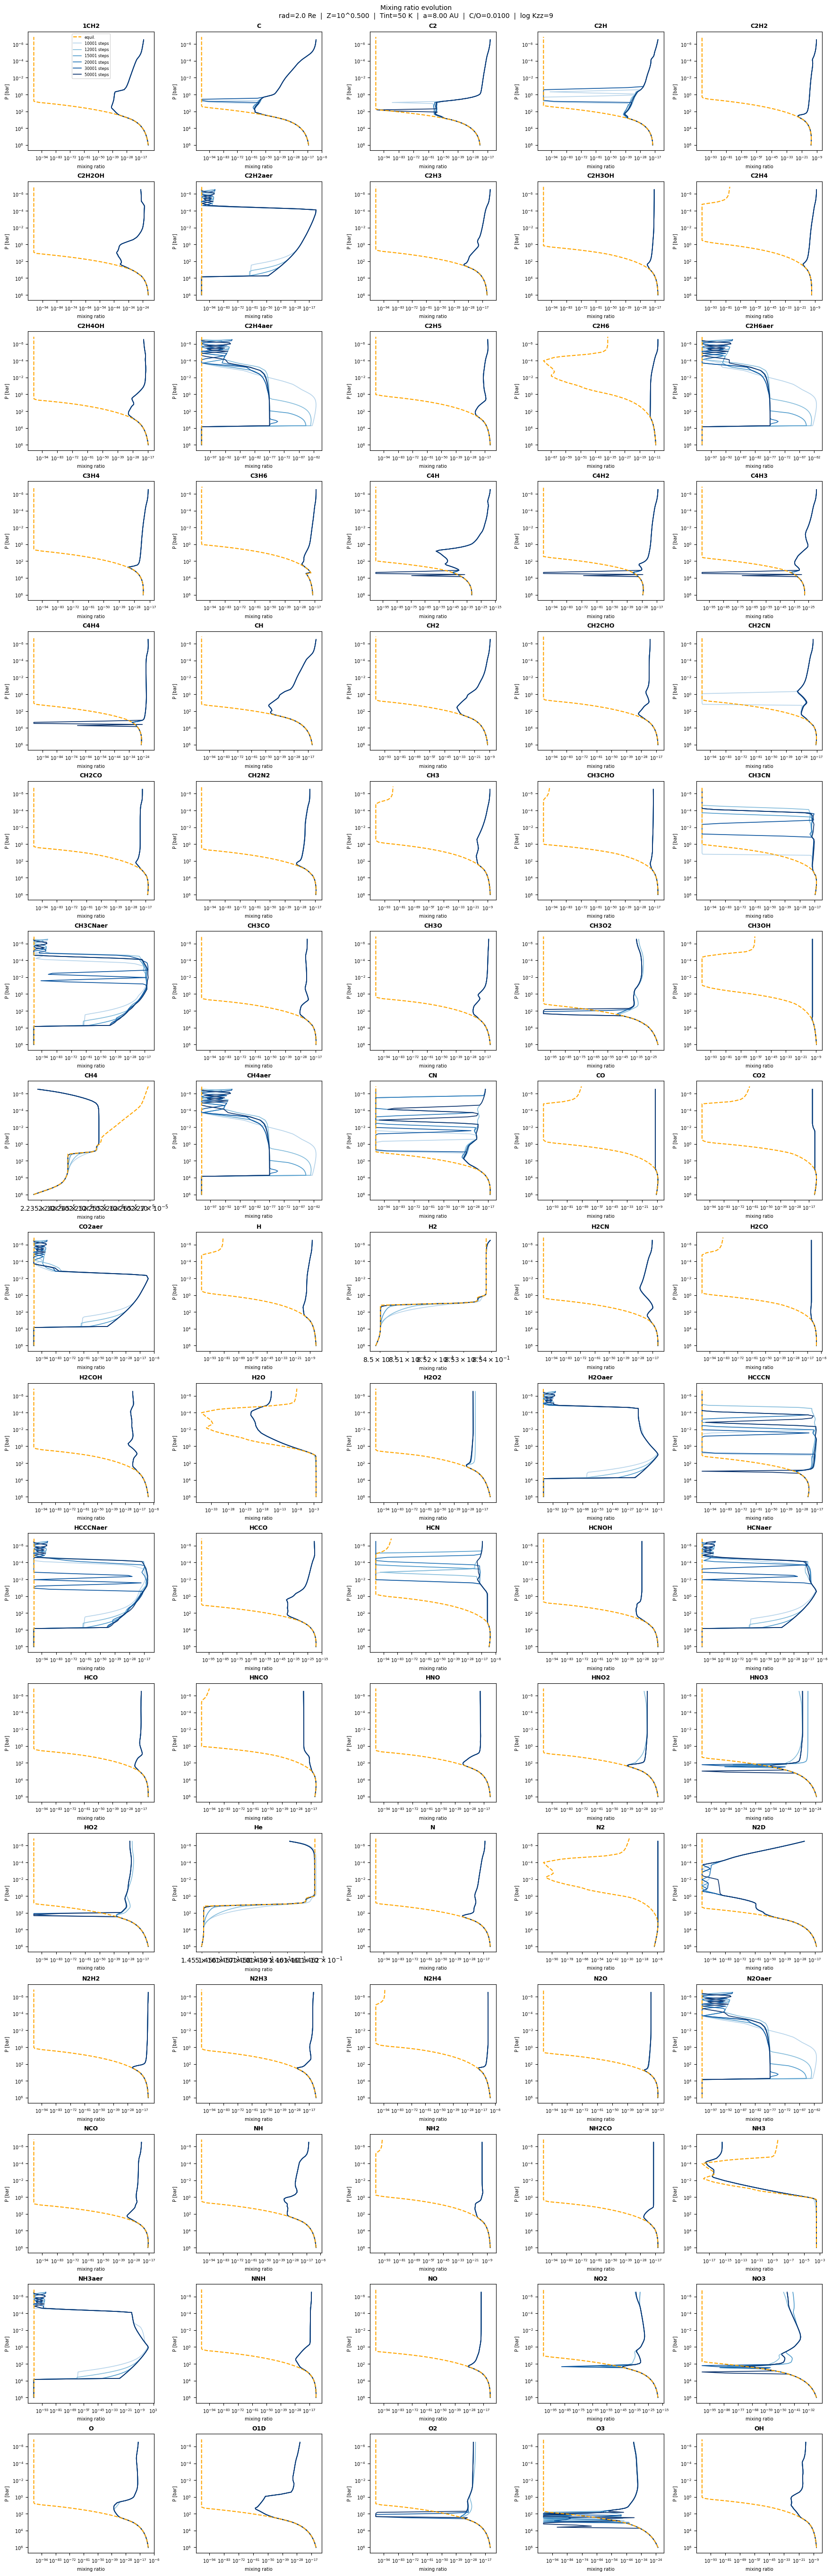

In [18]:
case_label = (f'rad={rad:.1f} Re  |  Z=10^{log_metal:.3f}  |  Tint={tint:.0f} K  |  '
              f'a={semi_major:.2f} AU  |  C/O={ctoO:.4f}  |  log Kzz={log_Kzz:.0f}')

step_keys = sorted(snapshots_rs.keys())
n_steps   = len(step_keys)
P_eq_bar  = soleq_rs['pressure'] / 1e6

# Color gradient: light blue = early, dark blue = late
blues = plt.cm.Blues(np.linspace(0.3, 1.0, n_steps))

ncols = 5
nrows = (len(mol_species) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 3.5, nrows * 3.2),
                         constrained_layout=True)
axes = np.array(axes).flatten()

for i, sp in enumerate(mol_species):
    ax = axes[i]
    if sp in soleq_rs:
        ax.plot(soleq_rs[sp], P_eq_bar,
                color='orange', lw=1.5, ls='--', zorder=5,
                label='equil.' if i == 0 else None)
    for j, step in enumerate(step_keys):
        sol   = snapshots_rs[step]
        P_bar = sol['pressure'] / 1e6
        if sp in sol:
            ax.plot(sol[sp], P_bar, color=blues[j], lw=1.2,
                    label=f'{step} steps' if i == 0 else None)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_title(sp, fontsize=9, fontweight='bold')
    ax.set_xlabel('mixing ratio', fontsize=7)
    ax.set_ylabel('P [bar]', fontsize=7)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=6, loc='best')
for j in range(len(mol_species), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Mixing ratio evolution\n{case_label}', fontsize=10)
plt.show()

### Plot 2 — Departure from Equilibrium at Final Step

Max |Δlog10(mixing ratio)| between the final photochem state and the initial equilibrium
across all pressure levels. Red bars = species that shifted by more than 1 decade.

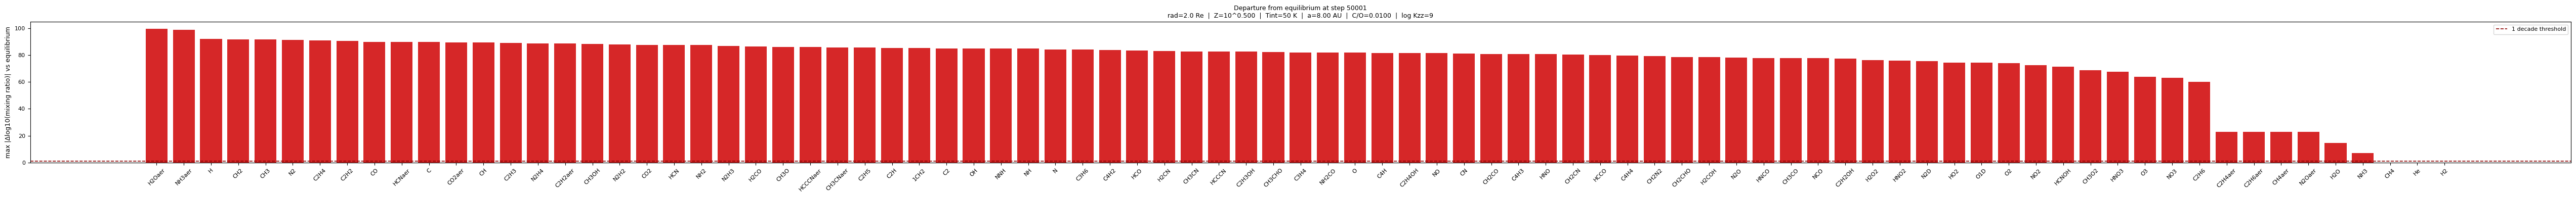

Species ranked by departure from equilibrium at step 50001:
  H2Oaer        max |dlog10| = 99.61  <- large departure
  NH3aer        max |dlog10| = 98.55  <- large departure
  H             max |dlog10| = 91.83  <- large departure
  CH2           max |dlog10| = 91.72  <- large departure
  CH3           max |dlog10| = 91.60  <- large departure
  N2            max |dlog10| = 91.35  <- large departure
  C2H4          max |dlog10| = 91.01  <- large departure
  C2H2          max |dlog10| = 90.64  <- large departure
  CO            max |dlog10| = 89.69  <- large departure
  HCNaer        max |dlog10| = 89.60  <- large departure
  C             max |dlog10| = 89.53  <- large departure
  CO2aer        max |dlog10| = 89.44  <- large departure
  CH            max |dlog10| = 89.34  <- large departure
  C2H3          max |dlog10| = 89.01  <- large departure
  N2H4          max |dlog10| = 88.44  <- large departure
  C2H2aer       max |dlog10| = 88.42  <- large departure
  CH3OH         max |dlog10|

In [19]:
final_step = list(snapshots_rs.keys())[-1]
sol_final  = snapshots_rs[final_step]
P_bar_f    = sol_final['pressure'] / 1e6
P_bar_eq   = soleq_rs['pressure'] / 1e6

log_diffs = {}
for sp in mol_species:
    if sp in sol_final and sp in soleq_rs:
        x_pc = np.interp(P_bar_eq[::-1], P_bar_f[::-1], sol_final[sp][::-1])[::-1]
        with np.errstate(divide='ignore', invalid='ignore'):
            diff = np.abs(
                np.log10(np.clip(x_pc,         1e-100, None)) -
                np.log10(np.clip(soleq_rs[sp], 1e-100, None))
            )
        log_diffs[sp] = float(np.nanmax(diff))

sorted_sp   = sorted(log_diffs, key=log_diffs.get, reverse=True)
sorted_diff = [log_diffs[s] for s in sorted_sp]

fig, ax = plt.subplots(figsize=(max(6, len(sorted_sp) * 0.6), 4))
ax.bar(sorted_sp, sorted_diff,
       color=['#d62728' if d > 1.0 else '#aec7e8' for d in sorted_diff])
ax.axhline(1.0, color='darkred', ls='--', lw=1.2, label='1 decade threshold')
ax.set_ylabel('max |Δlog10(mixing ratio)| vs equilibrium', fontsize=9)
ax.set_title(f'Departure from equilibrium at step {final_step}\n{case_label}', fontsize=9)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Species ranked by departure from equilibrium at step {final_step}:')
for sp, d in zip(sorted_sp, sorted_diff):
    flag = '  <- large departure' if d > 1.0 else ''
    print(f'  {sp:<12}  max |dlog10| = {d:.2f}{flag}')

### Plot 3 — Which Species Are Still Actively Changing?

Compares the last two checkpoint snapshots. Species with |Δlog10| > 0.1 between
the last two steps are the ones most directly causing non-convergence.

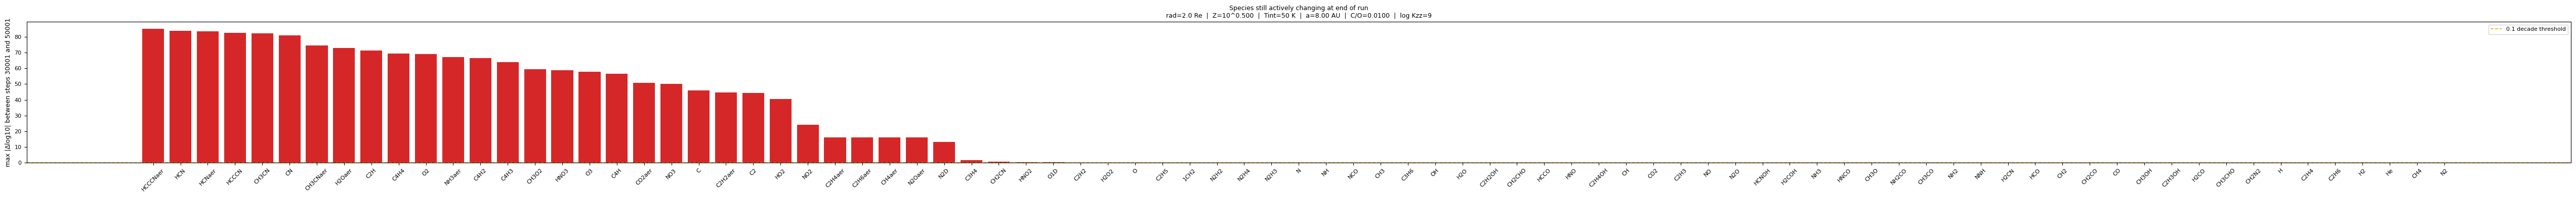

Species still moving between steps 30001 -> 50001 (most active first):
  HCCCNaer      max |dlog10| = 85.272  <- still changing significantly
  HCN           max |dlog10| = 83.721  <- still changing significantly
  HCNaer        max |dlog10| = 83.529  <- still changing significantly
  HCCCN         max |dlog10| = 82.662  <- still changing significantly
  CH3CN         max |dlog10| = 82.353  <- still changing significantly
  CN            max |dlog10| = 80.922  <- still changing significantly
  CH3CNaer      max |dlog10| = 74.543  <- still changing significantly
  H2Oaer        max |dlog10| = 72.933  <- still changing significantly
  C2H           max |dlog10| = 71.304  <- still changing significantly
  C4H4          max |dlog10| = 69.318  <- still changing significantly
  O2            max |dlog10| = 69.033  <- still changing significantly
  NH3aer        max |dlog10| = 67.178  <- still changing significantly
  C4H2          max |dlog10| = 66.506  <- still changing significantly
  C4H3

In [20]:
step_keys = sorted(snapshots_rs.keys())
if len(step_keys) >= 2:
    s_prev, s_last = step_keys[-2], step_keys[-1]
    sol_prev = snapshots_rs[s_prev]
    sol_last = snapshots_rs[s_last]
    P_prev   = sol_prev['pressure'] / 1e6
    P_last   = sol_last['pressure'] / 1e6

    still_moving = {}
    for sp in mol_species:
        if sp in sol_prev and sp in sol_last:
            x_prev = np.interp(P_last[::-1], P_prev[::-1], sol_prev[sp][::-1])[::-1]
            with np.errstate(divide='ignore', invalid='ignore'):
                diff = np.abs(
                    np.log10(np.clip(sol_last[sp], 1e-100, None)) -
                    np.log10(np.clip(x_prev,       1e-100, None))
                )
            still_moving[sp] = float(np.nanmax(diff))

    sorted_mv   = sorted(still_moving, key=still_moving.get, reverse=True)
    sorted_mv_d = [still_moving[s] for s in sorted_mv]

    fig, ax = plt.subplots(figsize=(max(6, len(sorted_mv) * 0.6), 4))
    ax.bar(sorted_mv, sorted_mv_d,
           color=['#d62728' if d > 0.1 else '#aec7e8' for d in sorted_mv_d])
    ax.axhline(0.1, color='orange', ls='--', lw=1.2, label='0.1 decade threshold')
    ax.set_ylabel(f'max |Δlog10| between steps {s_prev} and {s_last}', fontsize=9)
    ax.set_title(f'Species still actively changing at end of run\n{case_label}', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f'Species still moving between steps {s_prev} -> {s_last} (most active first):')
    for sp, d in zip(sorted_mv, sorted_mv_d):
        flag = '  <- still changing significantly' if d > 0.1 else ''
        print(f'  {sp:<12}  max |dlog10| = {d:.3f}{flag}')
else:
    print('Only one snapshot — cannot compare last two steps.')

### Plot 4 — Zoomed View of Actively Non-Converging Species

Only species with `still_moving > 0.1` at the last step. Useful for seeing
whether the non-convergence is localized to a specific pressure level.

Plotting 35 actively changing species: ['HCCCNaer', 'HCN', 'HCNaer', 'HCCCN', 'CH3CN', 'CN', 'CH3CNaer', 'H2Oaer', 'C2H', 'C4H4', 'O2', 'NH3aer', 'C4H2', 'C4H3', 'CH3O2', 'HNO3', 'O3', 'C4H', 'CO2aer', 'NO3', 'C', 'C2H2aer', 'C2', 'HO2', 'NO2', 'C2H4aer', 'C2H6aer', 'CH4aer', 'N2Oaer', 'N2D', 'C3H4', 'CH2CN', 'HNO2', 'O1D', 'C2H2']


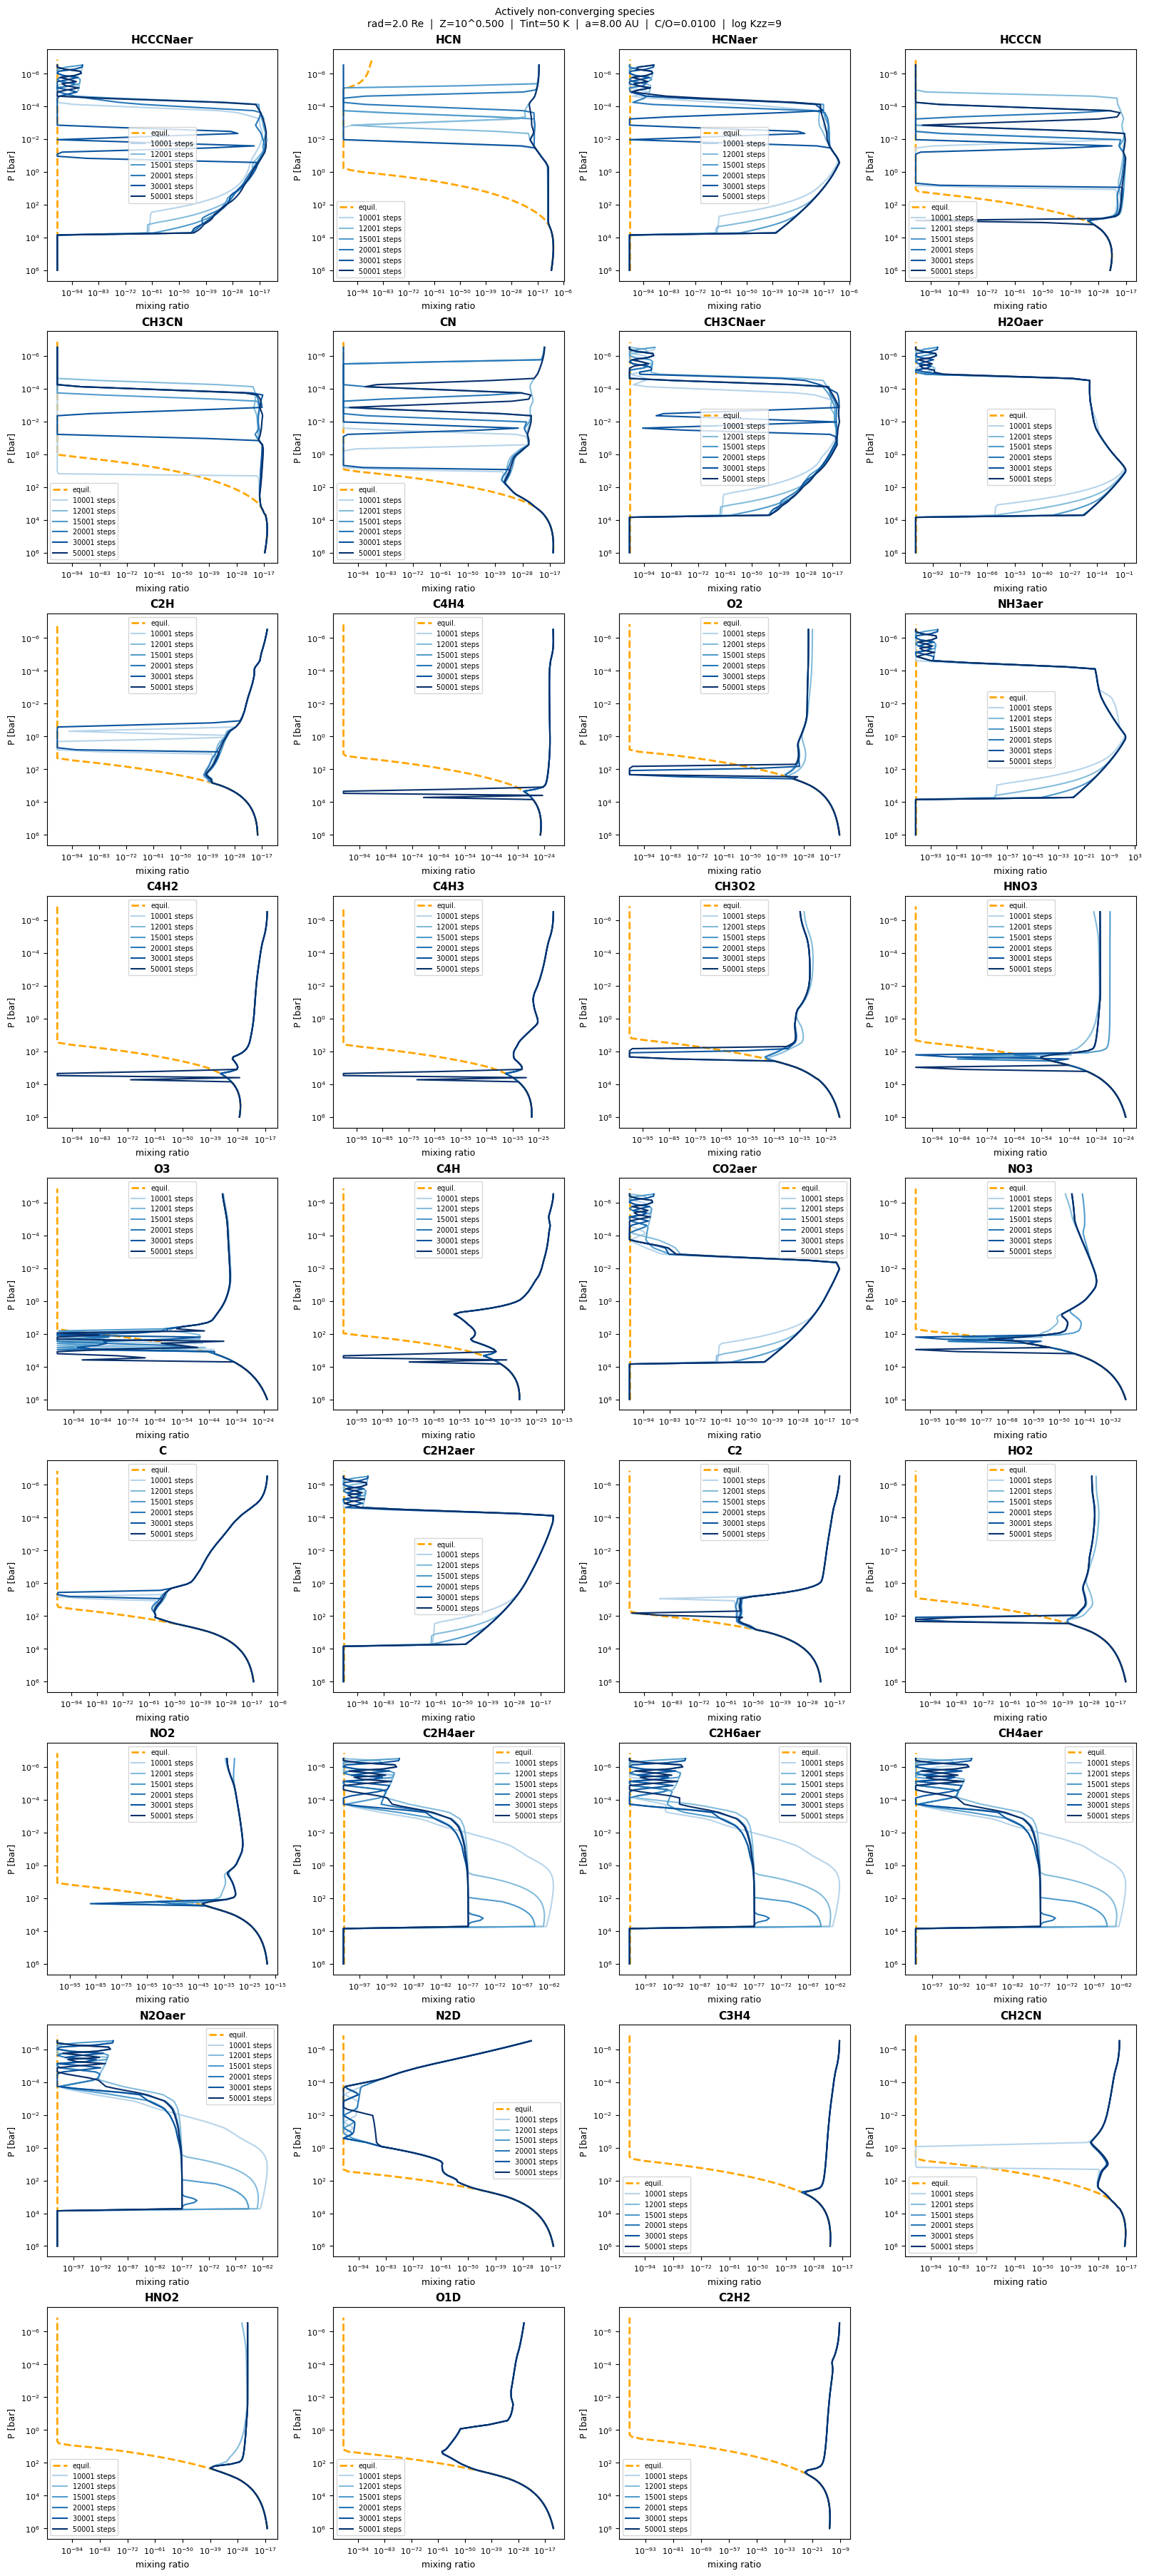

In [21]:
active_species = [sp for sp in sorted_mv if still_moving[sp] > 0.1]

if not active_species:
    print('No species above the 0.1 decade threshold — convergence was close.')
else:
    print(f'Plotting {len(active_species)} actively changing species: {active_species}')
    ncols = min(4, len(active_species))
    nrows = (len(active_species) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4.0, nrows * 4.0),
                             constrained_layout=True)
    axes = np.array(axes).flatten()
    blues = plt.cm.Blues(np.linspace(0.3, 1.0, len(step_keys)))

    for i, sp in enumerate(active_species):
        ax = axes[i]
        if sp in soleq_rs:
            ax.plot(soleq_rs[sp], soleq_rs['pressure'] / 1e6,
                    color='orange', lw=2.0, ls='--', label='equil.')
        for j, step in enumerate(sorted(snapshots_rs.keys())):
            sol = snapshots_rs[step]
            if sp in sol:
                ax.plot(sol[sp], sol['pressure'] / 1e6,
                        color=blues[j], lw=1.5, label=f'{step} steps')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.invert_yaxis()
        ax.set_title(sp, fontsize=11, fontweight='bold')
        ax.set_xlabel('mixing ratio', fontsize=9)
        ax.set_ylabel('P [bar]', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.legend(fontsize=7)

    for j in range(len(active_species), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Actively non-converging species\n{case_label}', fontsize=10)
    plt.show()

### Plot 5 — Notebook Result vs Grid-Stored Result

Compares the notebook's final diagnostic state (solid blue) against the result stored in
`Photochem_1D_lowmetal_restart.h5` for the same case (dashed red).  
Agreement confirms the notebook replicates the grid run faithfully.  
Divergence indicates environmental differences or that the grid stored a partially-converged state.

Grid result loaded for case 0.


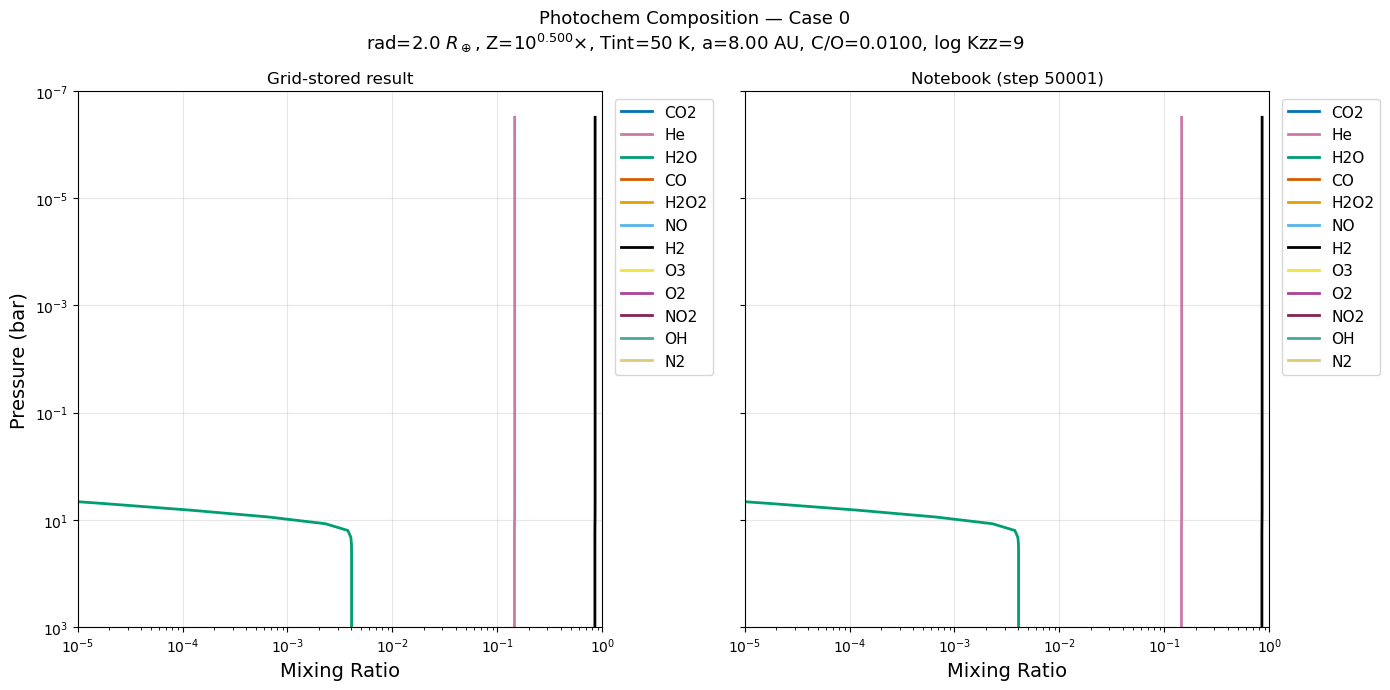

In [26]:
GRID_SHAPE = (1, 6, 8, 11, 5, 3)

def load_case_from_grid(h5_path, case_params, grid_shape=GRID_SHAPE):
    """Return (sol_grid, soleq_grid) dicts for the matching input row, or (None, None)."""
    with h5py.File(h5_path, 'r') as f:
        inputs   = f['inputs'][:]
        diffs    = np.abs(inputs - case_params).max(axis=1)
        flat_idx = int(np.argmin(diffs))
        if diffs[flat_idx] > 1e-4:
            return None, None
        multi_idx  = np.unravel_index(flat_idx, grid_shape)
        sol_grid   = {}
        soleq_grid = {}
        for key in f['results'].keys():
            val = np.array(f['results'][key][multi_idx])
            if key.endswith('_sol'):
                sol_grid[key[:-4]] = val
            elif key.endswith('_soleq'):
                soleq_grid[key[:-6]] = val
    return sol_grid, soleq_grid

# Load the grid-stored result for the current case
case_params          = np.array([rad, log_metal, tint, semi_major, ctoO, log_Kzz])
sol_grid, soleq_grid = load_case_from_grid(PC_H5, case_params)

if sol_grid is None:
    print('Case not found in grid h5 — it may not have run yet on Hyak.')
else:
    print(f'Grid result loaded for case {CASE_IDX}.')

    species_to_compare = ['CO2','He','H2O','CO', 'H2O2', 'NO', 'H2', 'O3', 'O2', 'NO2', 'OH', 'N2']
    colors_sp = ['#0072B2', '#CC79A7', '#009E73', '#D55E00',
                 '#E69F00', '#56B4E9', '#000000', '#F0E442',
                 '#AA4499', '#882255', '#44AA99', '#DDCC77']

    final_step = sorted(snapshots_rs.keys())[-1]
    sol_nb     = snapshots_rs[final_step]

    _case_label = (f'rad={rad:.1f} $R_\oplus$, Z=10$^{{{log_metal:.3f}}}$×, '
                   f'Tint={tint:.0f} K, a={semi_major:.2f} AU, '
                   f'C/O={ctoO:.4f}, log Kzz={log_Kzz:.0f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

    for sp, color in zip(species_to_compare, colors_sp):
        if sp in sol_grid:
            p_grid = np.array(sol_grid['pressure']) / 1e6
            axes[0].plot(sol_grid[sp], p_grid, color=color, lw=2, label=sp)
        if sp in sol_nb:
            p_nb = np.array(sol_nb['pressure']) / 1e6
            axes[1].plot(sol_nb[sp], p_nb, color=color, lw=2, label=sp)

    for ax, title in zip(axes, ['Grid-stored result', f'Notebook (step {final_step})']):
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.invert_yaxis()
        ax.set_xlim(1e-5, 1)
        ax.set_ylim(1000, 1e-7)
        ax.set_xlabel('Mixing Ratio', fontsize=14)
        ax.grid(alpha=0.3)
        ax.set_title(title, fontsize=12)
        ax.legend(ncol=1, fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left')

    axes[0].set_ylabel('Pressure (bar)', fontsize=14)
    fig.suptitle(f'Photochem Composition — Case {CASE_IDX}\n{_case_label}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Part 3: All Non-Converged Cases — Full Diagnostic Loop

Runs the same checkpoint analysis as Part 2 for all 9 non-converged cases.
Each case produces 4 plots:
1. Mixing ratio evolution (light→dark blue) with the grid-stored result overlaid (dotted red)
2. Departure from equilibrium at the final step
3. Species still actively changing between the last two checkpoints
4. Zoomed view of the most actively non-converging species

`load_case_from_grid` is defined in the Plot 5 cell above and must be run first.
Each case takes several minutes — expect the full loop to run for ~1 hour.

In [27]:
def run_full_diagnostic(rad, log_metal, tint, semi_major, ctoO, log_Kzz,
                        picaso_h5=None, pc_h5=None):
    """
    Full checkpoint diagnostic for one non-converged case.
    Produces 5 plots: mixing ratio evolution + grid overlay, departure from equilibrium,
    still-moving species, zoomed active species, and notebook vs grid comparison.
    """
    if picaso_h5 is None:
        picaso_h5 = PICASO_H5
    if pc_h5 is None:
        pc_h5 = PC_H5

    case_label = (f'rad={rad:.1f} Re  |  Z=10^{log_metal:.3f}  |  Tint={tint:.0f} K  |  '
                  f'a={semi_major:.2f} AU  |  C/O={ctoO:.4f}  |  log Kzz={log_Kzz:.0f}')
    print(f'  {case_label}')

    # 1. PICASO PT profile
    PT_list, _, picaso_status, picaso_error = Photochem_grid.find_PT_grid(
        filename=picaso_h5,
        rad_plan=rad, log10_planet_metallicity=log_metal,
        tint=tint, semi_major=semi_major, ctoO=ctoO,
        gridvals=PICASO_Climate_grid.get_gridvals_PICASO_TP()
    )
    if PT_list is None:
        print(f'  PICASO PT not found ({picaso_status}). Skipping.')
        return

    P_ext, T_ext = Photochem_grid.linear_extrapolate_TP(PT_list[0], PT_list[1])
    P_run = np.flip(P_ext * 1e6).copy()
    T_run = np.flip(T_ext).copy()

    # 2. Stellar flux + chemistry files (cached after first call)
    planet_Teq        = PICASO_Climate_grid.calc_Teq_SUN(distance_AU=semi_major)
    stellar_flux_file = f'sun_flux_file_{planet_Teq}'
    if not Path(stellar_flux_file).exists():
        star_spectrum.solar_spectrum(Teq=planet_Teq, outputfile=stellar_flux_file)

    zahnle_rx_and_thermo_files(
        atoms_names=['H', 'He', 'N', 'O', 'C'],
        rxns_filename='photochem_rxns.yaml',
        thermo_filename='photochem_thermo.yaml',
        remove_reaction_particles=True
    )

    # 3. Build EvoAtmosphereGasGiant (identical to grid script)
    mass_planet_earth = PICASO_Climate_grid.mass_from_radius_chen_kipping_2017(R_rearth=rad)
    mass_planet       = mass_planet_earth * 5.972e+24 * 1e3
    radius_planet     = rad * 6.371e+6 * 1e2

    pc_run = gasgiants.EvoAtmosphereGasGiant(
        mechanism_file='photochem_rxns.yaml',
        stellar_flux_file=stellar_flux_file,
        planet_mass=mass_planet,
        planet_radius=radius_planet,
        solar_zenith_angle=60,
        thermo_file='photochem_thermo.yaml'
    )
    pc_run.var.conv_longdy = 0.03
    pc_run.gdat.verbose    = False
    pr = pc_run.var.particle_radius
    pr[:, :] = 1e-3
    pc_run.var.particle_radius = pr

    molfracs_atoms_sun = np.ones(len(pc_run.gdat.gas.atoms_names)) * 1e-10
    comp = {'H': 9.21e-01, 'N': 6.23e-05, 'O': 4.51e-04,
            'C': 2.48e-04, 'S': 1.21e-05, 'He': 7.84e-02}
    tot  = sum(comp.values())
    for i_atom, atom in enumerate(pc_run.gdat.gas.atoms_names):
        molfracs_atoms_sun[i_atom] = comp.get(atom, 1e-10) / tot
    pc_run.gdat.gas.molfracs_atoms_sun = molfracs_atoms_sun

    Kzz_run = np.ones(P_run.shape[0]) * (10 ** log_Kzz)
    pc_run.gdat.BOA_pressure_factor = 3
    pc_run.initialize_to_climate_equilibrium_PT(P_run, T_run, Kzz_run, 10 ** log_metal, ctoO)

    soleq_diag  = pc_run.return_atmosphere(equilibrium=True)
    mol_species = sorted([k for k in soleq_diag.keys()
                          if k not in ('pressure', 'temperature', 'Kzz')])

    # 4. Checkpoint run (identical to grid script)
    snapshots      = {}
    converged_diag = False

    pc_run.gdat.max_total_step = 10000
    converged_diag = pc_run.find_steady_state()
    steps_done = pc_run.gdat.total_step_counter
    snapshots[steps_done] = pc_run.return_atmosphere()
    print(f'  Initial run: steps={steps_done}  {"CONVERGED" if converged_diag else "not converged"}')

    if not converged_diag:
        for budget in [12000, 15000, 20000, 30000, 50000]:
            try:
                pc_run.gdat.max_total_step = budget
                converged_diag = pc_run.find_steady_state()
                steps_done = pc_run.gdat.total_step_counter
                snapshots[steps_done] = pc_run.return_atmosphere()
                print(f'  Retry {budget}: steps={steps_done}  {"CONVERGED" if converged_diag else "not converged"}')
                if converged_diag:
                    break
            except Exception as exc:
                print(f'  Retry {budget}: exception {exc}')
                break

    # 5. Resample to 100 layers
    snapshots_rs = {
        step: Photochem_grid.interpolate_photochem_result_to_nlayers(s, nlayers=100)
        for step, s in snapshots.items()
    }
    soleq_rs  = Photochem_grid.interpolate_photochem_result_to_nlayers(soleq_diag, nlayers=100)
    step_keys = sorted(snapshots_rs.keys())
    n_steps   = len(step_keys)
    P_eq_bar  = soleq_rs['pressure'] / 1e6
    blues     = plt.cm.Blues(np.linspace(0.3, 1.0, n_steps))

    # 6. Load grid-stored result for overlay
    case_params    = np.array([rad, log_metal, tint, semi_major, ctoO, log_Kzz])
    sol_grid, _    = load_case_from_grid(pc_h5, case_params)
    grid_available = sol_grid is not None

    # Plot 1 — mixing ratio evolution + grid overlay
    ncols = 5
    nrows = (len(mol_species) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.5, nrows * 3.2),
                             constrained_layout=True)
    axes = np.array(axes).flatten()
    for i, sp in enumerate(mol_species):
        ax = axes[i]
        if sp in soleq_rs:
            ax.plot(soleq_rs[sp], P_eq_bar, color='orange', lw=1.5, ls='--',
                    label='equil.' if i == 0 else None)
        for j, step in enumerate(step_keys):
            s = snapshots_rs[step]
            if sp in s:
                ax.plot(s[sp], s['pressure'] / 1e6, color=blues[j], lw=1.2,
                        label=f'{step} steps' if i == 0 else None)
        if grid_available and sp in sol_grid:
            ax.plot(sol_grid[sp], sol_grid['pressure'] / 1e6,
                    color='crimson', lw=1.5, ls=':',
                    label='grid' if i == 0 else None)
        ax.set_xscale('log'); ax.set_yscale('log'); ax.invert_yaxis()
        ax.set_title(sp, fontsize=9, fontweight='bold')
        ax.set_xlabel('mixing ratio', fontsize=7)
        ax.set_ylabel('P [bar]', fontsize=7)
        ax.tick_params(labelsize=7)
    axes[0].legend(fontsize=6)
    for j in range(len(mol_species), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f'Mixing ratio evolution + grid result\n{case_label}', fontsize=10)
    plt.show()

    # Plot 2 — departure from equilibrium
    final_step = step_keys[-1]
    sol_final  = snapshots_rs[final_step]
    P_bar_f    = sol_final['pressure'] / 1e6

    log_diffs = {}
    for sp in mol_species:
        if sp in sol_final and sp in soleq_rs:
            x_pc = np.interp(P_eq_bar[::-1], P_bar_f[::-1], sol_final[sp][::-1])[::-1]
            with np.errstate(divide='ignore', invalid='ignore'):
                diff = np.abs(np.log10(np.clip(x_pc, 1e-100, None)) -
                              np.log10(np.clip(soleq_rs[sp], 1e-100, None)))
            log_diffs[sp] = float(np.nanmax(diff))

    sorted_sp   = sorted(log_diffs, key=log_diffs.get, reverse=True)
    sorted_diff = [log_diffs[s] for s in sorted_sp]

    fig, ax = plt.subplots(figsize=(max(6, len(sorted_sp) * 0.6), 4))
    ax.bar(sorted_sp, sorted_diff,
           color=['#d62728' if d > 1.0 else '#aec7e8' for d in sorted_diff])
    ax.axhline(1.0, color='darkred', ls='--', lw=1.2, label='1 decade threshold')
    ax.set_ylabel('max |Δlog10(mixing ratio)| vs equilibrium', fontsize=9)
    ax.set_title(f'Departure from equilibrium at step {final_step}\n{case_label}', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # Plot 3 — still-moving species
    still_moving = {}
    if len(step_keys) >= 2:
        s_prev, s_last = step_keys[-2], step_keys[-1]
        sol_prev = snapshots_rs[s_prev]
        sol_last = snapshots_rs[s_last]
        P_prev   = sol_prev['pressure'] / 1e6
        P_last   = sol_last['pressure'] / 1e6

        for sp in mol_species:
            if sp in sol_prev and sp in sol_last:
                x_prev = np.interp(P_last[::-1], P_prev[::-1], sol_prev[sp][::-1])[::-1]
                with np.errstate(divide='ignore', invalid='ignore'):
                    diff = np.abs(np.log10(np.clip(sol_last[sp], 1e-100, None)) -
                                  np.log10(np.clip(x_prev, 1e-100, None)))
                still_moving[sp] = float(np.nanmax(diff))

        sorted_mv   = sorted(still_moving, key=still_moving.get, reverse=True)
        sorted_mv_d = [still_moving[s] for s in sorted_mv]

        fig, ax = plt.subplots(figsize=(max(6, len(sorted_mv) * 0.6), 4))
        ax.bar(sorted_mv, sorted_mv_d,
               color=['#d62728' if d > 0.1 else '#aec7e8' for d in sorted_mv_d])
        ax.axhline(0.1, color='orange', ls='--', lw=1.2, label='0.1 decade threshold')
        ax.set_ylabel(f'max |Δlog10| between steps {s_prev} and {s_last}', fontsize=9)
        ax.set_title(f'Species still actively changing\n{case_label}', fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        # Plot 4 — zoomed active species
        active_species = [sp for sp in sorted_mv if still_moving[sp] > 0.1]
        if active_species:
            ncols_z = min(4, len(active_species))
            nrows_z = (len(active_species) + ncols_z - 1) // ncols_z
            fig, axes = plt.subplots(nrows_z, ncols_z,
                                     figsize=(ncols_z * 4.0, nrows_z * 4.0),
                                     constrained_layout=True)
            axes = np.array(axes).flatten()
            for i, sp in enumerate(active_species):
                ax = axes[i]
                if sp in soleq_rs:
                    ax.plot(soleq_rs[sp], soleq_rs['pressure'] / 1e6,
                            color='orange', lw=2.0, ls='--', label='equil.')
                for j, step in enumerate(step_keys):
                    s = snapshots_rs[step]
                    if sp in s:
                        ax.plot(s[sp], s['pressure'] / 1e6,
                                color=blues[j], lw=1.5, label=f'{step} steps')
                if grid_available and sp in sol_grid:
                    ax.plot(sol_grid[sp], sol_grid['pressure'] / 1e6,
                            color='crimson', lw=1.5, ls=':', label='grid')
                ax.set_xscale('log'); ax.set_yscale('log'); ax.invert_yaxis()
                ax.set_title(sp, fontsize=11, fontweight='bold')
                ax.set_xlabel('mixing ratio', fontsize=9)
                ax.set_ylabel('P [bar]', fontsize=9)
                ax.tick_params(labelsize=8)
                ax.legend(fontsize=7)
            for j in range(len(active_species), len(axes)):
                axes[j].set_visible(False)
            fig.suptitle(f'Actively non-converging species\n{case_label}', fontsize=10)
            plt.show()
        else:
            print('  No species above 0.1 decade threshold.')
    else:
        print('  Only one snapshot — cannot compare last two steps.')

    print(f'  Final status: {"Photochem-converged" if converged_diag else "Photochem-not-converged"}')

In [ ]:
for case_idx, row in enumerate(filtered):
    r, z, t, a, c, k = row
    print(f'\n{"#"*70}')
    print(f'CASE {case_idx} / {len(filtered) - 1}')
    run_full_diagnostic(r, z, t, a, c, k)


######################################################################
CASE 0 / 8
  rad=2.0 Re  |  Z=10^0.500  |  Tint=50 K  |  a=8.00 AU  |  C/O=0.0100  |  log Kzz=9
Was able to successfully find your input parameters in the PICASO TP profile grid!
